In [ ]:
#@title Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Part 1: Load/Analyze Data

I used a dataset called AI vs Human Text, which I obtained from Kaggle. The dataset was created by a Kaggle user named shanegerami and is publicly available for research and educational use. It contains a very large collection of text samples, each labeled as either AI-generated or Human-written. The goal of the dataset is to help build models that can distinguish between text written by people and text written by AI language models.

The link to the data: https://www.kaggle.com/datasets/shanegerami/ai-vs-human-texthttps://www.kaggle.com/datasets/shanegerami/ai-vs-human-text

The dataset includes over 500,000 samples. Due to run time constrain, I only use 50,000 samples to train and test my model. Each data point has two fields:

*   text — the actual text content
*   generated — the label (1 = AI-generated, 0 = human-written)

I access the dataset using the KaggleHub Python library, which downloads the dataset directly into my notebook environment. After downloading, I work with the CSV file using pandas.

I load this dataset via KaggleHub Python library and load it directly into my notebook (What I have done under).

Overall, this dataset is ideal for my project because it provides a large and realistic set of examples of human vs AI writing, allowing me to train and evaluate a model that attempts to detect AI-generated content.



In [ ]:
pip install kagglehub[hf-datasets]

In [ ]:
# Download dataset
import kagglehub
import os
from kagglehub import KaggleDatasetAdapter, dataset_load

# Set the path to the file you'd like to load
path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")
print("Dataset path:", path)
print("Files in dataset:", os.listdir(path))

# Load a Dataset with a specific version of a CSV, then remove a column
hf_dataset = kagglehub.dataset_load(
    KaggleDatasetAdapter.HUGGING_FACE,
    "shanegerami/ai-vs-human-text",
    "AI_Human.csv",
)
hf_dataset = hf_dataset.shuffle(seed=42).select(range(50000))
print("Hugging Face Dataset:", hf_dataset)
print(hf_dataset[0])

# Target variable: Generated by AI (1) or Human (0)

Using Colab cache for faster access to the 'ai-vs-human-text' dataset.
Dataset path: /kaggle/input/ai-vs-human-text
Files in dataset: ['AI_Human.csv']
Using Colab cache for faster access to the 'ai-vs-human-text' dataset.
Hugging Face Dataset: Dataset({
    features: ['text', 'generated'],
    num_rows: 50000
})
{'text': 'Curiosity is in the nature of humans and curiosity has gotten us to many places. If Christopher Columbus did not travel to India, the British would have not found North America. Likewise in space exploration, we must be curious about the planet Venus. Venus is a planet that is very similar to earth in many forms. The reason for studying space exploration is explained in the article "The Challenge of exploring Venus". Although the Venus\' conditions are very absurd, but the doors that it can open are well worth the handwork needed to explore the planet. That is why the author explains that Venus is a planet that is worth exploring due to exploring Venus is able to open

##Load your dataset / Implement your dataloader

In [ ]:
# necessary imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from collections import Counter
from datasets import load_dataset
import numpy as np
import re
from sklearn.model_selection import train_test_split

In [ ]:
MAX_VOCAB_SIZE = 10000  # Number of words in vocabulary
MAX_SEQUENCE_LENGTH = 500  # Max words per review
EMBEDDING_DIM = 100  # Word embedding size

# Select good hyperparameters
HIDDEN_DIM = 80  # RNN hidden state size
BATCH_SIZE = 32  # Number of samples in each minibatch
EPOCHS = 10  # Number of times to go through the training data
LEARNING_RATE = 0.01  # Learning rate for the optimizer

In [ ]:
# - load your dataset and set up your dataloader
# If applicable, please include your data with your final submission
# along with instructions for how to load it


# Split dataset into training and testing datase

X = np.array(hf_dataset["text"])
y = np.array(hf_dataset["generated"])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42,test_size = 0.3)

print(f"Loaded {len(X_train)} training samples and {len(X_test)} test samples.")

Loaded 35000 training samples and 15000 test samples.


In [ ]:

# Tokenization (Basic Word Indexing)
#  Implement the preprocess_text function
# - Convert text to lowercase
# - Remove punctuation using regex
# - Split text into individual words (tokenization)
# - Return a list of words
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    return words


# Build Vocabulary
word_counter = Counter()
for review in X_train:
    word_counter.update(preprocess_text(review))

vocab = ["<PAD>", "<UNK>"] + [word for word, _ in word_counter.most_common(MAX_VOCAB_SIZE - 2)]
word_to_idx = {word: idx for idx, word in enumerate(vocab)}

# Convert text to numerical sequences
def text_to_sequence(text, word_to_idx, max_length):
    words = preprocess_text(text)
    sequence = [word_to_idx.get(word, 1) for word in words]  # 1 is "<UNK>"
    if len(sequence) < max_length:
        sequence += [0] * (max_length - len(sequence))  # Padding
    return sequence[:max_length]


X_train_seq = [text_to_sequence(review, word_to_idx, MAX_SEQUENCE_LENGTH) for review in X_train]
X_test_seq = [text_to_sequence(review, word_to_idx, MAX_SEQUENCE_LENGTH) for review in X_test]

#  Convert data to PyTorch tensors
# - Convert X_train_seq, y_train, X_test_seq, y_test to PyTorch tensors
# - Use torch.tensor() with the correct dtype (long for X and float32 for y)
X_train_tensor = torch.tensor(X_train_seq, dtype = torch.long)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype = torch.long)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)


# Create PyTorch Dataset & DataLoader
class HFDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Valid, Train, Test Data set
train_dataset = HFDataset(X_train_tensor, y_train_tensor)

train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset,
    [train_size, val_size],
    generator = torch.Generator().manual_seed(42)
)

test_dataset = HFDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)
val_loader   = DataLoader(val_dataset,   batch_size = BATCH_SIZE)

# - if not already done, please make a train/val/test split of your dataset

##Dataset Analyis Statistics

In [ ]:
#  - code for collecting statistics from your dataset / plots and analysis

Label


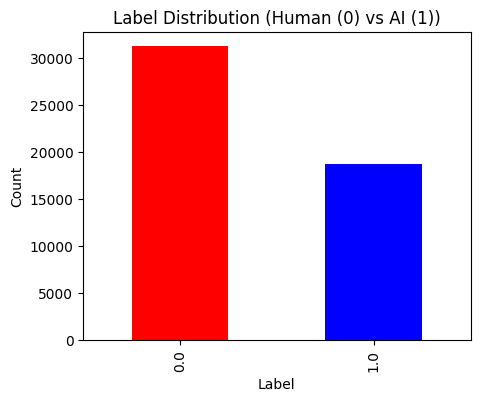

Text Length


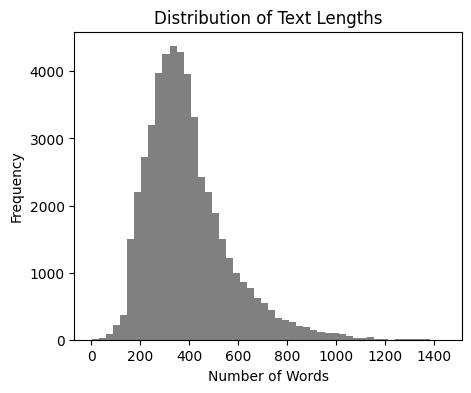

Common words


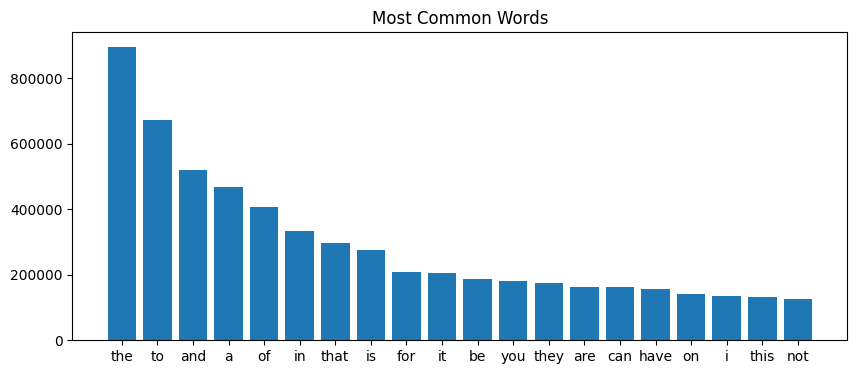

Avg Words


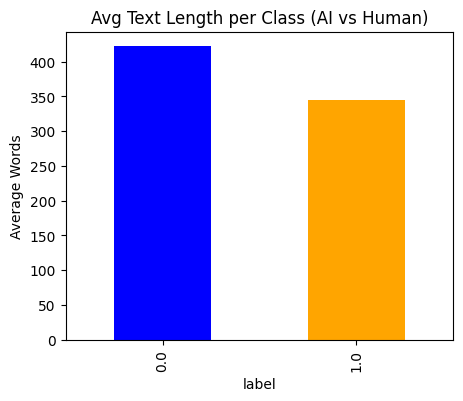

In [ ]:
import pandas as pd
from collections import Counter

# Put dataset into a pandas DataFrame for easy analysis
df = pd.DataFrame({
    "text": hf_dataset["text"],
    "label": hf_dataset["generated"]
})


# Label distribution
label_counts = df["label"].value_counts()
print("Label")

plt.figure(figsize = (5,4))
label_counts.plot(kind = "bar", color=["red", "blue"])
plt.title("Label Distribution (Human (0) vs AI (1))")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Text length analysis
df["length"] = df["text"].str.split().str.len()

print("Text Length")

plt.figure(figsize = (5,4))
plt.hist(df["length"], bins = 50, color = "gray")
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

#  Most common words
all_words = []
for t in df["text"]:
    all_words.extend(t.lower().split())

word_counts = Counter(all_words)
most_common = word_counts.most_common(20)

print("Common words")

# Bar chart
words, freqs = zip(*most_common)
plt.figure(figsize = (10,4))
plt.bar(words, freqs)
plt.title("Most Common Words")
# plt.xticks(rotation = 45)
plt.show()

#  Average words per class (AI vs Human)
avg_len_by_class = df.groupby("label")["length"].mean()
print("Avg Words")

plt.figure(figsize = (5,4))
avg_len_by_class.plot(kind = "bar", color = ["blue","orange"])
plt.title("Avg Text Length per Class (AI vs Human)")
plt.ylabel("Average Words")
plt.show()

Analysis and statistics of the data:

I tried to analyse my data in several different way:
 * Label distribution: How is the data being distributed between these labels
 * Distribution text length: What is the text distribution between the samples
 * What are the most common words in the samples
 * What are the average length of each label

 By analysing these aspect of the dataset, I could have a deeper understand about it to train my model better. For example, one of the thing that I can learn from the analysis is that AI text samples usually have longer length than Human text samples.

# Part 2: Literature Review

– RoBERTa and Bi-LSTM for Human vs AI Generated Text Detection

Link to the paper: https://ceur-ws.org/Vol-3740/paper-272.pdf

* In this paper the author used 2 models for the classification between human and AI text. Their first approach was a RoBERTa transformer, which they fine-tuned on the dataset after starting from pretrained language model weights. They also trained a bidirectional LSTM classifier that processes token embeddings and uses the final forward and backward hidden states for prediction. In addition, they tried combining the outputs of RoBERTa and the Bi-LSTM in an ensemble to further improve performance. Overall, their methodology followed a standard text classification pipeline: tokenize the input, convert tokens to embeddings, feed them into either RoBERTa or the Bi-LSTM, and pass the resulting representation through a linear layer to predict whether the text is AI-generated or human-written. They also mentioned using AdamW as their optimizer, crossentropy as their lost function and the batch size was 32 when they trained their models.



---


– Text classification using machine learning methods (Bogdan Oancea)


Link to the paper: https://arxiv.org/pdf/2502.19801

* This paper explores several machine learning models for text classification. The authors build different models with the goal of classifying text samples, and some of the methods they use are ones we have already seen in class, such as Logistic Regression, k-Nearest Neighbors, and Neural Networks. They also use preprocessing techniques we learned, including word embedding, specifically Word2Vec which turn text into numerical vectors. The paper also applies grid search and cross validation to help find the best hyperparameters for each model. Their results show that models like Random Forests, SVM with radial kernels, and Artificial Neural Networks achieve the highest accuracy, while Word2Vec and other embedding approaches help improve performance. Overall, this paper gives a basic comparison of how different machine learning models behave on a text classification task.



---

– Artificial Intelligence vs Human: Decoding Text Authenticity with Transformers

Gifu et al. (2025)

Link to the paper: https://www.mdpi.com/1999-5903/17/1/38

* This paper use transformer models to classify human and AI text. The authors used models such as BERT and RoBERTa following by a similar procedure to what we have learned in class: taking the input text, tokenizing it, converting it into embeddings, and passing it through a transformer encoder. They also used Adam as their optimizer, RELU and softmax as their loss function for training the models. Their experiment showed that their models can get up to 70% accuracy on the choosen dataset. The result is encouraging, they also reveal persistent challenges in distinguishing between machinegenerated and human-written content, particularly when handling unseen data during
training.

Throughout all of these paper I noticed that all the authors seem to approach this dataset in a similar way: tokenized the text and convert them into number by using word embedding methods before input them into their choosen model. Many authors chose similar loss function such as softmax, Adam as their optimizer for the model, and many of them use Word2Vec word embedding methods to pre-process the dataset. Most of the models used in these papers are RNNs model but, Transformer is also very promising for text classification.

# Part 3: Implement networks in PyTorch

Note of warning here: Depending on how easily you can allocate GPU resources, you may want to make your network much shallower so that you can train it more easily
Aim to have one gradient update take no more than a few seconds
May also want to reduce the number of training steps if training is too slow

In [ ]:
# - implement your PyTorch Module

# Define RNN Model
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        #  Define the layers of the RNN model
        # - Embedding layer to convert word indices to dense vectors
        # - RNN layer (LSTM/RNN) to process sequential data
        # - Fully connected (linear) layer to map hidden state to output
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = 0)
        self.LSTM = nn.LSTM(input_size = embedding_dim, hidden_size = hidden_dim, num_layers = 2, batch_first=True)
        self.h2o = nn.Linear(hidden_dim, 2)
        self.softmax = nn.Softmax(dim=1)


    def forward(self, x):
        # Implement the forward pass
        embedded = self.embedding(x)
        lengths = (x != 0).sum(dim = 1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths=lengths,
            batch_first = True,
            enforce_sorted = False
        )
        # rnn_out, hidden  = self.LSTM(packed)
        # layer1, layer2 = hidden
        _, (hidden_states, cell_states) = self.LSTM(packed)

        last_hidden = hidden_states[-1]
        output = self.h2o(last_hidden)
        output = self.softmax(output)
        return output


# Initialize Model
model = SentimentLSTM(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(device)

# Define a good Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

def para_sum(model):
  sum = 0
  for param in model.parameters():
    sum += torch.sum(param.data)
  return sum

In [ ]:
#- implement your training loop
# Training Loop
train_acc = []
val_acc = []
epochs = []
correct = 0
total = 0


print("Training model.")
for epoch in range(EPOCHS):
    # setting the model to train mode
    model.train()
    epoch_loss = 0

    # iterating over the training data in batches
    for batch_X, batch_y in train_loader:
        batch_X  = batch_X.to(device)
        batch_y  = batch_y.to(device)

        # Implement the training step
        # - Reset the optimizer's gradients
        # - Forward pass: compute model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_acc.append(correct / total)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")
    epochs.append(epoch)

    # Validate as training
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
      for val_X, val_y in val_loader:
        val_X = val_X.to(device)
        val_y = val_y.to(device)

        outputs = model(val_X)
        preds = outputs.argmax(dim=1)
        correct += (preds == val_y).sum().item()
        total += val_y.size(0)

    val_acc.append(correct / total)


Training model.
Epoch 1/10, Loss: 0.4259
Epoch 2/10, Loss: 0.3456
Epoch 3/10, Loss: 0.3385
Epoch 4/10, Loss: 0.3290
Epoch 5/10, Loss: 0.3281
Epoch 6/10, Loss: 0.3266
Epoch 7/10, Loss: 0.3237
Epoch 8/10, Loss: 0.3216
Epoch 9/10, Loss: 0.3232
Epoch 10/10, Loss: 0.3242


In [ ]:
def checkAcc():
  model.eval()
  correct = 0
  total = 0
  y_true, y_pred = [], []
  with torch.no_grad():
      for batch_X, batch_y in test_loader:
          batch_X = batch_X.to(device)
          batch_y = batch_y.to(device)
          outputs = model(batch_X)
          preds = outputs.argmax(dim=1)
          correct += (preds == batch_y).sum().item()
          total   += batch_y.size(0)

  accuracy = correct / total
  return accuracy

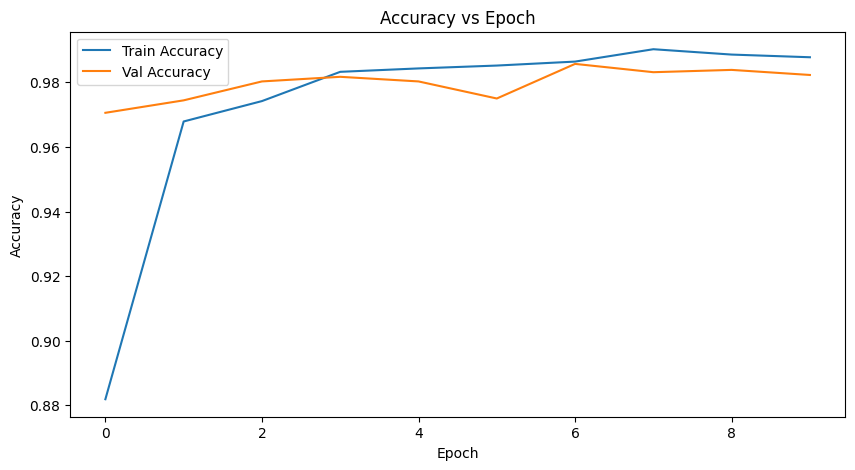

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc,   label="Val Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

I design my model to be a LSTM model since my dataset consist of sequatial text. I think LSTM is a great model to classify this type of data because it can understand the order of words and capture context across a sentence. I also embed each word into a sequence and feed it into my model so it can learn meaningful patterns in the text.

Instead of a single-layer LSTM, I designed mine with an additional layer so it can learn more complex patterns in the text. I selected Adam as my optimizer and CrossEntropyLoss as my loss function to help the model train efficiently and handle multi-class predictions.

# Part 4: Run Hyperparameter Experiments

In [ ]:
# Define a hyperparameter grid
param_grid = {
    'hidden_dim':   [32, 64, 128],
    'learning_rate':[0.01, 0.005, 0.001],
}

In [ ]:
# Train and evaluate the model by searching hyperparameters within the grid, and record the best scores and the corresponding hyperparameters
def train_model(hidden_dim, lr):
    model = SentimentLSTM(len(vocab), EMBEDDING_DIM, hidden_dim).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    for epoch in range(3):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim = 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total
    return val_acc

hidden_dim = 32, lr = 0.01
val_acc = 0.9743
hidden_dim = 32, lr = 0.005
val_acc = 0.9556
hidden_dim = 32, lr = 0.001
val_acc = 0.9261
hidden_dim = 64, lr = 0.01
val_acc = 0.9140
hidden_dim = 64, lr = 0.005
val_acc = 0.9824
hidden_dim = 64, lr = 0.001
val_acc = 0.9096
hidden_dim = 128, lr = 0.01
val_acc = 0.6184
hidden_dim = 128, lr = 0.005
val_acc = 0.9670
hidden_dim = 128, lr = 0.001
val_acc = 0.9733

Best acc: 0.9824285714285714
Best params: {'hidden_dim': 64, 'learning_rate': 0.005}


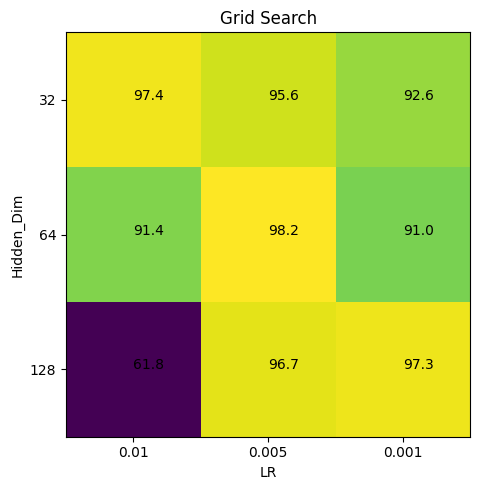

In [ ]:
# - perform hyperparameter grid searches and plot accuracies

hiddens = param_grid["hidden_dim"]
LR     = param_grid["learning_rate"]

results = []

#Grid search
grid = np.zeros((len(hiddens), len(LR)))

best_params = {}
best_acc = 0.0

for i, h in enumerate(hiddens):
    for j, lr in enumerate(LR):
        print(f"hidden_dim = {h}, lr = {lr}")
        val_acc = train_model(h, lr)
        print(f"val_acc = {val_acc:.4f}")

        grid[i, j] = val_acc

        if val_acc > best_acc:
            best_acc = val_acc
            best_params = {"hidden_dim": h, "learning_rate": lr}

print("\nBest acc:", best_acc)
print("Best params:", best_params)

plt.figure(figsize=(6, 5))
plt.imshow(grid)

plt.xticks(range(len(LR)), LR)
plt.yticks(range(len(hiddens)), hiddens)
plt.xlabel("LR")
plt.ylabel("Hidden_Dim")
plt.title("Grid Search")

# write accuracy values on the cells
for i in range(len(hiddens)):
    for j in range(len(LR)):
        plt.text(j, i, f"{grid[i, j]*100:.1f}")

plt.tight_layout()
plt.show()

In [ ]:
# - perform other experiments and plot accuracies
# Pre-train the model on a different data set

# Load new data set
path = kagglehub.dataset_download("pratyushpuri/ai-vs-human-content-detection-1000-record-in-2025")
print("Dataset path:", path)
print("Files in dataset:", os.listdir(path))

# Load the latest version
hf_pre_dataset = kagglehub.load_dataset(
  KaggleDatasetAdapter.HUGGING_FACE,
  "pratyushpuri/ai-vs-human-content-detection-1000-record-in-2025",
  'ai_human_content_detection_dataset.csv',
)

print("Hugging Face Dataset:", hf_pre_dataset)


Using Colab cache for faster access to the 'ai-vs-human-content-detection-1000-record-in-2025' dataset.
Dataset path: /kaggle/input/ai-vs-human-content-detection-1000-record-in-2025
Files in dataset: ['ai_human_content_detection_dataset.csv']


/tmp/ipython-input-957699655.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  hf_pre_dataset = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ai-vs-human-content-detection-1000-record-in-2025' dataset.
Hugging Face Dataset: Dataset({
    features: ['text_content', 'content_type', 'word_count', 'character_count', 'sentence_count', 'lexical_diversity', 'avg_sentence_length', 'avg_word_length', 'punctuation_ratio', 'flesch_reading_ease', 'gunning_fog_index', 'grammar_errors', 'passive_voice_ratio', 'predictability_score', 'burstiness', 'sentiment_score', 'label'],
    num_rows: 1367
})


In [ ]:
# Split dataset into training and testing datase

X_pre = np.array(hf_pre_dataset["text_content"])
y_pre = np.array(hf_pre_dataset["label"])

print(f"Loaded {len(X_pre)} pre - training samples.")

Loaded 1367 pre - training samples.


In [ ]:
HIDDEN_DIM = 80  # RNN hidden state size
BATCH_SIZE = 32  # Number of samples in each minibatch
EPOCHS = 10  # Number of times to go through the training data
LEARNING_RATE = 0.01  # Learning rate for the optimizer

In [ ]:
X_pre_seq = [text_to_sequence(review, word_to_idx, MAX_SEQUENCE_LENGTH) for review in X_pre]

#  Convert data to PyTorch tensors
# - Convert X_train_seq, y_train, X_test_seq, y_test to PyTorch tensors
# - Use torch.tensor() with the correct dtype (long for X and float32 for y)
X_pre_tensor = torch.tensor(X_pre_seq, dtype = torch.long)
y_pre_tensor = torch.tensor(y_pre, dtype = torch.long)


# Create Valid, Train, Test Data set
pre_train_dataset = HFDataset(X_pre_tensor, y_pre_tensor)
pre_train_loader = DataLoader(pre_train_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
# Initialize Model
model = SentimentLSTM(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(device)

# Define a good Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [ ]:
# Training Loop
print("Training model.")
for epoch in range(EPOCHS):
    # setting the model to train mode
    model.train()
    epoch_loss = 0

    # iterating over the training data in batches
    for batch_X, batch_y in pre_train_loader:
        batch_X  = batch_X.to(device)
        batch_y  = batch_y.to(device)

        # Implement the training step
        # - Reset the optimizer's gradients
        # - Forward pass: compute model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

Training model.
Epoch 1/10, Loss: 0.0343
Epoch 2/10, Loss: 0.0327
Epoch 3/10, Loss: 0.0264
Epoch 4/10, Loss: 0.0215
Epoch 5/10, Loss: 0.0195
Epoch 6/10, Loss: 0.0180
Epoch 7/10, Loss: 0.0182
Epoch 8/10, Loss: 0.0183
Epoch 9/10, Loss: 0.0186
Epoch 10/10, Loss: 0.0180


In [ ]:
# Test Accuracy after pre-train
# Evaluation
acc = checkAcc()
print(f"Accuracy after pre-train model: {acc:.4f}")

Accuracy after pre-train model: 0.4947


In [ ]:
# Train it normally with the usual data set
print("Training model.")
for epoch in range(EPOCHS):
    # setting the model to train mode
    model.train()
    epoch_loss = 0

    # iterating over the training data in batches
    for batch_X, batch_y in train_loader:
        batch_X  = batch_X.to(device)
        batch_y  = batch_y.to(device)

        # Implement the training step
        # - Reset the optimizer's gradients
        # - Forward pass: compute model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

Training model.
Epoch 1/10, Loss: 0.4686
Epoch 2/10, Loss: 0.3530
Epoch 3/10, Loss: 0.3487
Epoch 4/10, Loss: 0.3468
Epoch 5/10, Loss: 0.3386
Epoch 6/10, Loss: 0.3337
Epoch 7/10, Loss: 0.3365
Epoch 8/10, Loss: 0.3385
Epoch 9/10, Loss: 0.3437
Epoch 10/10, Loss: 0.3307


In [ ]:
# Evaluation
acc = checkAcc()
print(f"Accuracy after training the pre-train model: {acc:.4f}")

Accuracy after training the pre-train model: 0.9792


In [ ]:
#- calculate the final test accuracy
val_acc = train_model(64, 0.005)
print(f"Final accuracy: {val_acc:.4f}")

Final accuracy: 0.9743



* For my experiments, I tested two different approaches to improve my model. First, I performed a grid search find the best hyperparameters, such as learning rate and hidden size, to see which combination would give the best accuracy. This allowed me to choose the most effective configuration to train the model.
*  Second, I pre-trained my model on a different dataset with similar labels before actually training it on my main dataset. The idea was to let the model learn general text patterns from a related source so it could start with better initial weights. After pre-training, the model adapted faster and performed better when trained on my actual classification task